In [1]:
import networkx as nx
import numpy as np
from collections import deque, Counter
import matplotlib.pyplot as plt
from auxilary_unparallelized import local_complementation, local_scaling, bitpack_decode, bitpack_encode, draw_graph
from itertools import permutations, combinations
from data_analysis_functions import *
import math
import random
from isomorphism_method import *
import os
import multiprocessing
import subprocess #get  C file
import concurrent.futures 
import time
# from orbital_graphs import create_orbital_graph, orbit_search_isomorphic_from_file, circular_subgraph_layout, draw_subgraph_inside_circle,plot_graph
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path

In [3]:
#Setup assumed 
n=7
d=3

In [4]:
#Functions (TODO: At the end will be moved to the data analysis file py file)
def approximate_aspl(graph, sample_size=10000):
    """
    Approximates the Average Shortest Path Length (ASPL) by sampling node pairs.

    Parameters:
    graph (networkx.Graph): Input graph.
    sample_size (int): Number of node pairs to sample.

    Returns:
    float: Approximate ASPL of the graph.
    """
    nodes = list(graph.nodes())
    total_dist = 0
    valid_pairs = 0

    for _ in range(sample_size):
        u, v = random.sample(nodes, 2)  # Randomly select two nodes
        try:
            total_dist += nx.shortest_path_length(graph, source=u, target=v)
            valid_pairs += 1
        except nx.NetworkXNoPath:
            continue  # Skip if no path exists

    return total_dist / valid_pairs if valid_pairs > 0 else float('inf')

In [13]:
g = nx.read_edgelist(f"orbits_d{d}_n{n}_separated/orbit_9", nodetype=int)
print("Number of nodes:",len(list(g.nodes())))
print("Number of edges",len(list(g.edges())))

Number of nodes: 338868
Number of edges 3554136


In [6]:
samples = 1000
approx_aspl_value = approximate_aspl(g,1000)
# print(f"Approx ASPL : {approx_aspl_value}")

Approx ASPL : 4.753


Overall Mean of Approximate ASPL: 5.8853
Overall Standard Deviation of Approximate ASPL: 0.0232


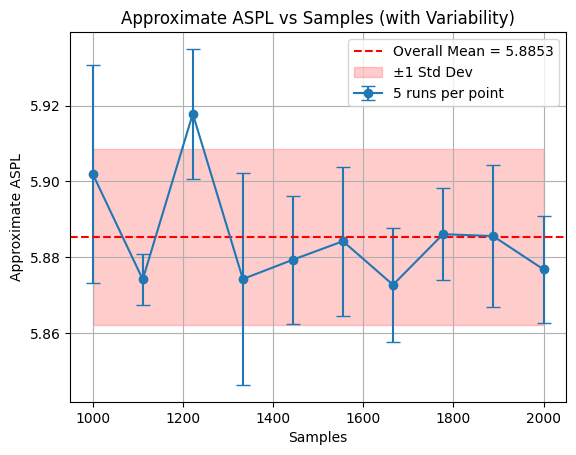

In [14]:
starting = 1000
finishing = 2000
points = 10
repeats = 5  # Number of repetitions for each sample point

samples = np.linspace(starting, finishing, points).astype(int)

# Perform multiple calculations for each sample point
y_values = np.array([[approximate_aspl(g, n) for _ in range(repeats)] for n in samples])

# Calculate mean and standard deviation for each sample point
means = y_values.mean(axis=1)
std_devs = y_values.std(axis=1)

# Calculate overall mean and standard deviation
overall_mean = y_values.mean()
overall_std = y_values.std()

print(f"Overall Mean of Approximate ASPL: {overall_mean:.4f}")
print(f"Overall Standard Deviation of Approximate ASPL: {overall_std:.4f}")

# Create the plot with error bars
plt.errorbar(samples, means, yerr=std_devs, fmt='-o', capsize=5, label=f'{repeats} runs per point')

# Display the overall mean and standard deviation on the plot
plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Overall Mean = {overall_mean:.4f}')
plt.fill_between(samples, overall_mean - overall_std, overall_mean + overall_std, color='red', alpha=0.2, label=f'±1 Std Dev')

plt.xlabel('Samples')
plt.ylabel('Approximate ASPL')
plt.title('Approximate ASPL vs Samples (with Variability)')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
g = nx.read_edgelist(f"orbits_d{d}_n{n}_separated/orbit_0", nodetype=int)
print("Number of nodes:",len(list(g.nodes())))
print("Number of edges",len(list(g.edges())))

Number of nodes: 48207
Number of edges 502080


In [58]:
starting = 1000 #Number of Samples Start
finishing = 10000 #Number of Samples End
points = 100 #Number of points between the range
repeats = 2  # Number of repetitions for each sample point

def statistics_approx_aspl(graph,initial_num_pairs,final_num_pair, samples_per_num_pairs, num_of_runs):
    samples = np.linspace(initial_num_pairs, final_num_pair, samples_per_num_pairs).astype(int)
    y_values = np.array([[approximate_aspl(graph, n) for _ in range(num_of_runs)] for n in samples])

    # Calculate mean and standard deviation for each sample point
    means = y_values.mean(axis=1)
    std_devs = y_values.std(axis=1)

    # Calculate overall mean and standard deviation
    overall_mean = y_values.mean()
    overall_std = y_values.std()
    return means, std_devs, overall_mean, overall_std






ar_mean, ar_std, tot_mean, tot_std = statistics_approx_aspl(g, starting,finishing,points,repeats)
print("Mean:",tot_mean)
print("Std:",tot_std)
print(f"Range: {tot_mean-tot_std} till {tot_mean+tot_std}")

Mean: 3.7054855838623433
Std: 0.0154992628161886
Range: 3.6899863210461548 till 3.720984846678532


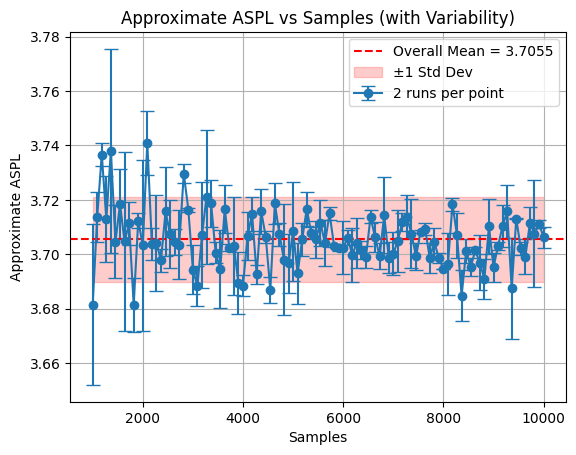

In [59]:
def plot_aspl_results(starting, finishing, points, repeats, means, std_devs, overall_mean, overall_std):
    """
    Plot the Approximate ASPL with error bars, overall mean, and variability.

    Parameters:
    - starting: Starting sample size.
    - finishing: Finishing sample size.
    - points: Number of sample points.
    - repeats: Number of repetitions per sample point.
    - means: Mean ASPL values for each sample point.
    - std_devs: Standard deviation for each sample point.
    - overall_mean: Overall mean ASPL across all samples and repetitions.
    - overall_std: Overall standard deviation ASPL across all samples and repetitions.
    """
    samples = np.linspace(starting, finishing, points).astype(int)

    # Create the plot with error bars
    plt.errorbar(samples, means, yerr=std_devs, fmt='-o', capsize=5, label=f'{repeats} runs per point')

    # Display the overall mean and standard deviation on the plot
    plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Overall Mean = {overall_mean:.4f}')
    plt.fill_between(samples, overall_mean - overall_std, overall_mean + overall_std, color='red', alpha=0.2, label=f'±1 Std Dev')

    plt.xlabel('Samples')
    plt.ylabel('Approximate ASPL')
    plt.title('Approximate ASPL vs Samples (with Variability)')
    plt.grid(True)
    plt.legend()
    plt.show()

# Usage example
plot_aspl_results(starting, finishing, points, repeats, ar_mean, ar_std, tot_mean, tot_std)

Calculate the residuals for n = 6.

In [47]:
d = 3
n = 6

starting = 1000
finishing = 2000
points = 10 #Number of points between the range
repeats = 2  # Number of repetitions for each sample point

exact_aspl = []
heut_aspl = []

for cnt in range(3,n+1):
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        print(f"Starting orbits_d{d}_n{cnt}_separated/{file}")
        g = nx.read_edgelist(f"orbits_d{d}_n{cnt}_separated/{file}", nodetype=int)
        temp_ex_aspl = avg_of_distance_matrix(g)
        exact_aspl.append(temp_ex_aspl)
        _, _, tot_mean, tot_std = statistics_approx_aspl(g, starting,finishing,points,repeats)
        heut_aspl.append(tot_mean)

# print(exact_aspl)
# print(heut_aspl)





Starting orbits_d3_n3_separated/orbit_0
Starting orbits_d3_n4_separated/orbit_0
Starting orbits_d3_n4_separated/orbit_1
Starting orbits_d3_n4_separated/orbit_2
Starting orbits_d3_n5_separated/orbit_0
Starting orbits_d3_n5_separated/orbit_1
Starting orbits_d3_n5_separated/orbit_2
Starting orbits_d3_n5_separated/orbit_3
Starting orbits_d3_n5_separated/orbit_4
Starting orbits_d3_n6_separated/orbit_0
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/3d/sh6jhl692_90_wc18d07vyww0000gn/T/ipykernel_10852/3153537535.py", line 18, in <module>
    temp_ex_aspl = avg_of_distance_matrix(g)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/konstantinosrafailrevis/Desktop/PhD/year_2/qudit-lc/data_analysis_functions.py", line 119, in avg_of_distance_matrix
    return nx.average_shortest_path_length(graph)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/networkx/utils/backends.py", line 412, in __call__
    return self.orig_func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/networkx/algorithms/

Exact ASPL: [1.3333333333333333, 1.5555555555555556, 2.175675675675676, 1.2666666666666666, 2.663273428008881, 2.5279949953081013, 3.010251659719006, 2.5491118077324972, 1.5818181818181818, 4.169115852933138, 2.8426439793034155, 3.416417256326004, 3.1811161715722927, 4.160690686599863, 3.2765996135924538, 3.5096468595066757, 1.8131868131868132, 3.1452460383653045, 3.3436784724104145, 3.851497814742812, 3.4968257908923253, 3.517248075142812, 2.75592203898051, 2.7866728011655546, 2.8366751458925634, 2.8366751458925634, 2.8988922457200403, 2.6080695220360024, 2.462937062937063, 2.214356929212363]
Heuristic ASPL: [1.3376034395054444, 1.5610483832847442, 2.183959772282648, 1.26725399504215, 2.6624342619119363, 2.521309307660739, 3.0145416287814846, 2.5521494420413253, 1.5852454435265733, 4.169862672124234, 2.841956278454045, 3.4164341446833255, 3.1864698167808028, 4.160586415796315, 3.271419517652005, 3.5117521730094134, 1.8078961866265122, 3.1430682036685127, 3.3433250815078432, 3.85094669

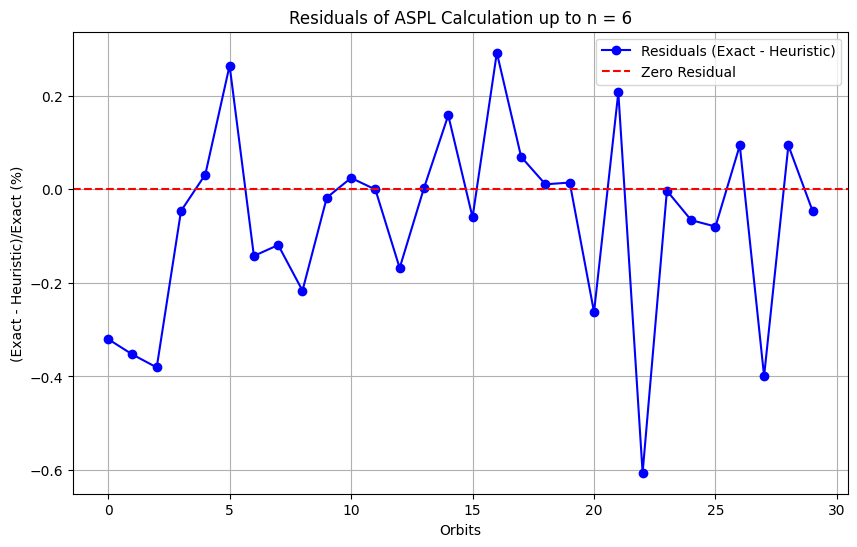

In [ ]:
# Calculate residuals (Exact - Heuristic)/Exact times 100
residuals = (np.array(exact_aspl) - np.array(heut_aspl))*100/np.array(exact_aspl)

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals, 'o-', label='Residuals (Exact - Heuristic)', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Orbits')
plt.ylabel('(Exact - Heuristic)/Exact (%)')
plt.title('Residuals of ASPL Calculation up to n = 6')
plt.legend()
plt.grid(True)
plt.show()

Residuals for all data less than 1 MB

In [61]:
with open("og_data/join_og_mean_path_length.txt", "r") as f:
    exact_aspl_7_up_to_1_mb = eval(f.read())

d = 3
n = 7

starting = 1000 #Number of Samples Start
finishing = 10000 #Number of Samples End
points = 10 #Number of points between the range
repeats = 2  # Number of repetitions for each sample point

heut_aspl = []

for cnt in range(3,n+1):
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        print(f"Starting orbits_d{d}_n{cnt}_separated/{file}")
        g = nx.read_edgelist(f"orbits_d{d}_n{cnt}_separated/{file}", nodetype=int)
        _, _, tot_mean, tot_std = statistics_approx_aspl(g, starting,finishing,points,repeats)
        heut_aspl.append(tot_mean)


Starting orbits_d3_n3_separated/orbit_0
Starting orbits_d3_n4_separated/orbit_0
Starting orbits_d3_n4_separated/orbit_1
Starting orbits_d3_n4_separated/orbit_2
Starting orbits_d3_n5_separated/orbit_0
Starting orbits_d3_n5_separated/orbit_1
Starting orbits_d3_n5_separated/orbit_2
Starting orbits_d3_n5_separated/orbit_3
Starting orbits_d3_n5_separated/orbit_4
Starting orbits_d3_n6_separated/orbit_0
Starting orbits_d3_n6_separated/orbit_1
Starting orbits_d3_n6_separated/orbit_2
Starting orbits_d3_n6_separated/orbit_3
Starting orbits_d3_n6_separated/orbit_4
Starting orbits_d3_n6_separated/orbit_5
Starting orbits_d3_n6_separated/orbit_6
Starting orbits_d3_n6_separated/orbit_7
Starting orbits_d3_n6_separated/orbit_8
Starting orbits_d3_n6_separated/orbit_9
Starting orbits_d3_n6_separated/orbit_10
Starting orbits_d3_n6_separated/orbit_11
Starting orbits_d3_n6_separated/orbit_12
Starting orbits_d3_n6_separated/orbit_13
Starting orbits_d3_n6_separated/orbit_14
Starting orbits_d3_n6_separated/orb

In [66]:
create_file = False

if create_file:
    with open('og_data/heut_aspl_large_run.txt', 'w') as f:
        f.write(str(heut_aspl))

103

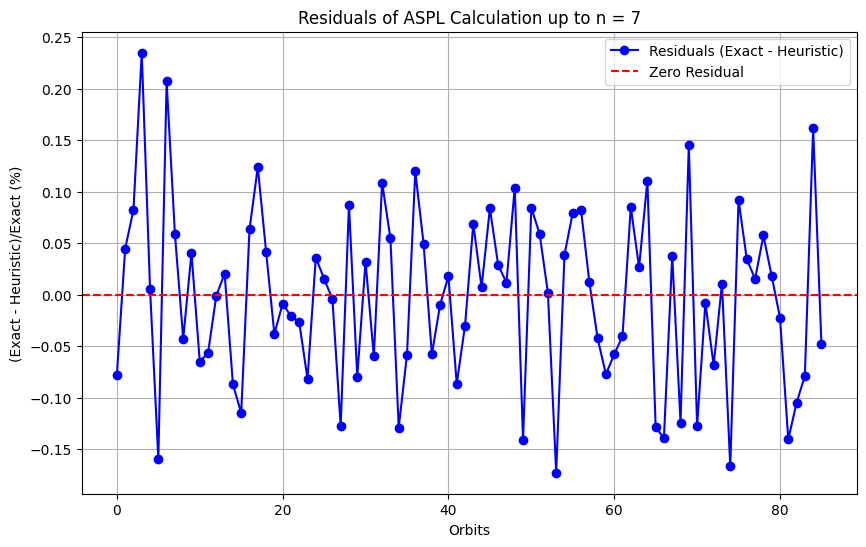

In [67]:
# Assuming exact_aspl_7_up_to_1_mb and heut_aspl are already defined as lists or arrays
exact_aspl_7_up_to_1_mb = np.array(exact_aspl_7_up_to_1_mb)
heut_aspl = np.array(heut_aspl)

# Create a mask to exclude cases where exact_aspl_7_up_to_1_mb is 0
mask = exact_aspl_7_up_to_1_mb != 0

# Calculate residuals
residuals = (exact_aspl_7_up_to_1_mb[mask] - heut_aspl[mask]) * 100 / exact_aspl_7_up_to_1_mb[mask]

if create_file:
    with open('og_data/residuals_aspl_large_run.txt', 'w') as f:
        f.write(str(residuals))


# Plot the residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals, 'o-', label='Residuals (Exact - Heuristic)', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Orbits')
plt.ylabel('(Exact - Heuristic)/Exact (%)')
plt.title('Residuals of ASPL Calculation up to n = 7')
plt.legend()
plt.grid(True)

# Save the figure as a PNG image
plt.savefig('og_figures/aspl_residuals.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Save the residual with avg, std and error bars

Mean of Residuals: -0.0023%
Standard Deviation of Residuals: 0.0861%


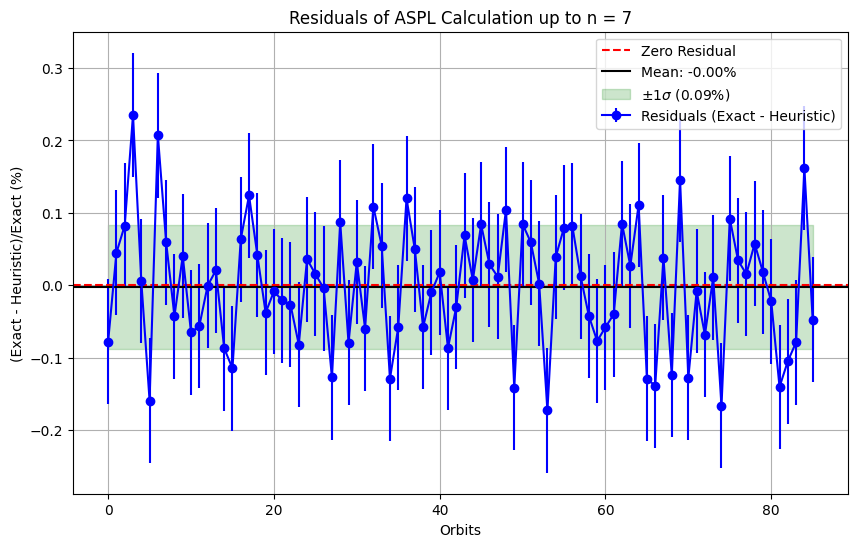

In [73]:
# Save residuals to a file if needed
if create_file:
    with open('og_data/residuals_aspl_large_run.txt', 'w') as f:
        f.write(str(residuals))

# Calculate statistics for the residuals
mean_residuals = np.mean(residuals)
std_residuals = np.std(residuals)

print(f"Mean of Residuals: {mean_residuals:.4f}%")
print(f"Standard Deviation of Residuals: {std_residuals:.4f}%")

# Plot the residuals with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(len(residuals)), residuals, yerr=std_residuals, fmt='o-', label='Residuals (Exact - Heuristic)', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')

# Add mean and error range
plt.axhline(y=mean_residuals, color='black', linestyle='-', label=f'Mean: {mean_residuals:.2f}%')
plt.fill_between(np.arange(len(residuals)), mean_residuals - std_residuals, mean_residuals + std_residuals, color='green', alpha=0.2, label=f'±1$\sigma$ ({std_residuals:.2f}%)')

# Labels and title
plt.xlabel('Orbits')
plt.ylabel('(Exact - Heuristic)/Exact (%)')
plt.title('Residuals of ASPL Calculation up to n = 7')
plt.legend()
plt.grid(True)

# Save the figure as a PNG image
plt.savefig('og_figures/aspl_residuals_with_error_bars.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Add the probabilistic results only for the masked data and get the final data points ASLP

[1.33333333 1.55555556 2.17567568 1.26666667 2.66327343 2.527995
 3.01025166 2.54911181 1.58181818 4.16911585 2.84264398 3.41641726
 3.18111617 4.16069069 3.27659961 3.50964686 1.81318681 3.14524604
 3.34367847 3.85149781 3.49682579 3.51724808 2.75592204 2.7866728
 2.83667515 2.83667515 2.89889225 2.60806952 2.46293706 2.21435693
 4.78403714 4.72413981 3.7124093  5.00895402 5.17788081 4.89079933
 4.41883948 5.51519911 4.77942147 5.88889234 5.3273277  5.52196306
 4.70388409 4.88965151 5.28688885 4.41840499 5.3304744  5.50431565
 5.33479712 4.99522992 4.68382189 4.68491577 4.75058797 5.08425766
 3.37857932 4.11659215 3.93509733 4.96075973 4.43178918 5.32492028
 4.09520136 4.58694067 4.90369224 4.11954104 4.69867268 3.36087558
 4.10896046 4.16378426 4.0808451  4.98863373 4.02952263 4.74308032
 4.95932315 4.38059268 4.16378426 4.68491577 4.52483524 4.07910328
 3.87451408 1.86666667 4.14668082 4.29427693 4.27860737 3.66498961
 3.65733492 2.90272953 4.45729831 2.8198024  3.60509445 3.1285478

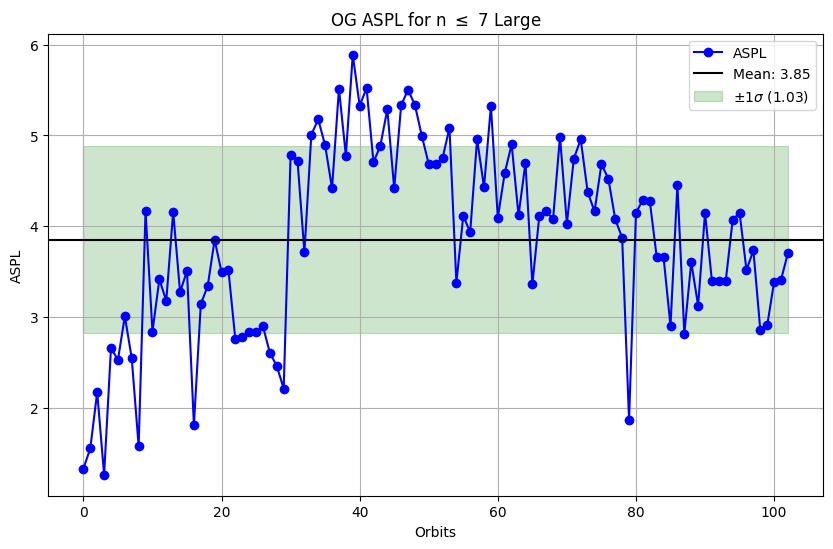

In [90]:
# Create a new array where zeros in exact_aspl_7_up_to_1_mb are replaced by heut_aspl
corrected_aspl = np.where(exact_aspl_7_up_to_1_mb == 0, heut_aspl, exact_aspl_7_up_to_1_mb)
print(corrected_aspl)

# # Save the corrected array to a file
# with open('og_data/join_final_aspl_large_run.txt', 'w') as f:
#     f.write(str(corrected_aspl))

# Save the corrected array
np.savetxt('og_data/join_final_aspl_large_run.txt', corrected_aspl)

# Calculate mean and standard deviation of corrected_aspl
mean_aspl = np.mean(corrected_aspl)
std_aspl = np.std(corrected_aspl)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(corrected_aspl, 'o-', label='ASPL', color='blue')

# Add mean line and ±1σ range
plt.axhline(y=mean_aspl, color='black', linestyle='-', label=f'Mean: {mean_aspl:.2f}')
plt.fill_between(np.arange(len(corrected_aspl)), mean_aspl - std_aspl, mean_aspl + std_aspl,
                 color='green', alpha=0.2, label=f'±1$\sigma$ ({std_aspl:.2f})')

# Labels and title
plt.xlabel('Orbits')
plt.ylabel('ASPL')
plt.title('OG ASPL for n $\leq$ 7 Large')
plt.legend()
plt.grid(True)

# Save the figure
plt.savefig('og_figures/final_og_aspl.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()